# PCA Dimensionality Reduction

Scale cleaned features, inspect explained variance, and review component weights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (path / "notebooks").is_dir() and (path / "data").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the repository root or notebooks directory.")

CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "edu_growth_cleaned.csv"
PCA_DATA_PATH = PROJECT_ROOT / "data" / "pca_transformed" / "edu_growth_pca.csv"


In [2]:
df = pd.read_csv(CLEANED_DATA_PATH)

df.shape

(46500, 102)

In [3]:
df = pd.read_csv(CLEANED_DATA_PATH)

df.shape

(46500, 102)

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.columns.tolist()

Rows: 46500
Columns: 102


['roll_no',
 'full_name',
 'class_section',
 'overall_attendance_pct',
 'theory_attendance_pct',
 'practical_attendance_pct',
 'previous_cgpa',
 'medical_leave_days',
 'society_participation_pc',
 'sports_activity_level',
 'final_semester_grade',
 'coa_attendance_pct',
 'maths4_attendance_pct',
 'dstl_attendance_pct',
 'ds_attendance_pct',
 'python_attendance_pct',
 'cyber_attendance_pct',
 'lab_ds_attendance_pct',
 'lab_python_attendance_pct',
 'lab_coa_attendance_pct',
 'lab_cyber_attendance_pct',
 'coa_st1_marks',
 'coa_st2_marks',
 'coa_put_marks',
 'coa_unit_1_marks',
 'coa_unit_2_marks',
 'coa_unit_3_marks',
 'coa_unit_4_marks',
 'coa_unit_5_marks',
 'coa_assignment_score',
 'coa_assignment_delay_hours',
 'coa_quiz_score',
 'maths4_st1_marks',
 'maths4_st2_marks',
 'maths4_put_marks',
 'maths4_unit_1_marks',
 'maths4_unit_2_marks',
 'maths4_unit_3_marks',
 'maths4_unit_4_marks',
 'maths4_unit_5_marks',
 'maths4_assignment_score',
 'maths4_assignment_delay_hours',
 'maths4_quiz_sc

In [5]:
df.dtypes.value_counts()

float64    95
int64       4
str         3
Name: count, dtype: int64

In [6]:
df.select_dtypes(include=["object", "str"]).columns.tolist()

['full_name', 'class_section', 'sports_activity_level']

In [7]:
pca_data = df.drop(columns=[
    "roll_no",
    "full_name",
    "class_section",
    "sports_activity_level",
    "final_semester_grade"
])

pca_data.shape

(46500, 97)

we also remove target column coz pca not aaply on target col 

In [8]:
pca_data.isnull().sum().sum()

np.int64(2434)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data)

X_scaled.shape

(46500, 97)

In [10]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [11]:
explained_variance = pca.explained_variance_ratio_

explained_variance[:10]

AttributeError: 'PCA' object has no attribute 'explained_variance_ratio_'

In [ ]:
import numpy as np

cumulative_variance = np.cumsum(explained_variance)

cumulative_variance[:10]

array([0.35491698, 0.3811869 , 0.39625395, 0.41116409, 0.42590607,
       0.44060746, 0.45522786, 0.46909972, 0.47951882, 0.48983201])

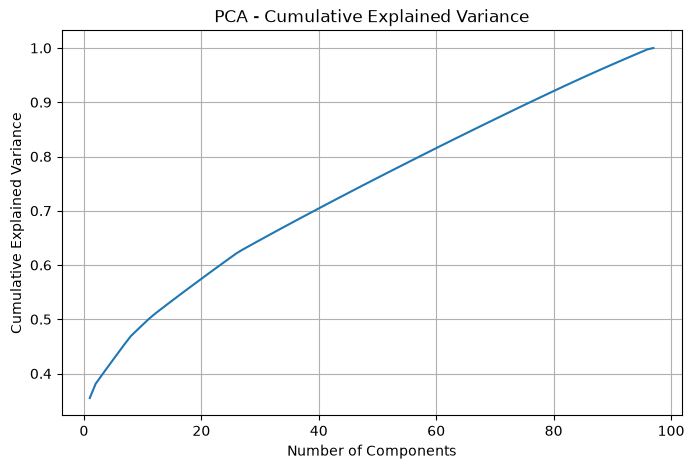

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")

plt.grid()
plt.show()

In [ ]:
n_components = np.argmax(cumulative_variance >= 0.90) + 1

n_components

np.int64(76)

In [ ]:
pca_reduced = PCA(n_components=76)

X_reduced = pca_reduced.fit_transform(X_scaled)

X_reduced.shape

(46500, 76)

In [ ]:
pca_reduced.explained_variance_ratio_.sum()

np.float64(0.9000948665995514)

In [ ]:
pca_df = pd.DataFrame(
    X_reduced,
    columns=[f"PC{i}" for i in range(1, 77)]
)

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC67,PC68,PC69,PC70,PC71,PC72,PC73,PC74,PC75,PC76
0,-8.194402,-1.442886,1.336789,-0.796124,0.310187,-0.373139,-1.435118,-0.305310,-1.190087,-0.480513,...,-0.503131,-0.571468,0.041206,-0.115060,0.949435,-0.047100,-0.384068,0.388874,-0.377090,0.409594
1,-2.246314,0.680040,-2.741411,-0.102395,0.817295,1.483698,1.641043,-0.720726,-0.852746,-0.877203,...,-0.167532,0.281399,-0.463658,0.431156,-0.718987,-0.737947,-0.472535,0.558646,-0.679452,0.816291
2,1.613592,-3.580045,-1.092298,1.086412,-0.726903,1.193066,1.528142,-0.028005,0.322567,0.021702,...,-0.311095,-0.039778,-0.361821,-0.571086,0.115926,0.321655,0.224569,-0.104365,-0.477441,0.145605
3,5.689165,0.224209,0.665012,0.483754,0.406727,-1.598164,1.353087,0.735022,0.034092,-0.187674,...,0.106546,-0.656405,-0.362119,-0.257059,0.967816,-0.743263,-0.286299,0.030040,0.169556,-0.233967
4,-0.032570,0.595563,0.695673,-2.268675,1.252964,-0.132046,-1.628797,-0.545720,-1.805325,4.187371,...,0.143781,0.108366,0.871006,0.071837,-0.508272,0.217115,0.295923,-0.080696,-1.116543,-0.434408


In [ ]:
loadings = pd.DataFrame(
    pca_reduced.components_.T,
    index=pca_data.columns,
    columns=[f"PC{i}" for i in range(1, 77)]
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC67,PC68,PC69,PC70,PC71,PC72,PC73,PC74,PC75,PC76
overall_attendance_pct,0.110718,0.244115,-0.012039,0.004229,-0.001790,-0.001196,-0.000115,0.014060,-0.003902,-0.011846,...,0.012803,0.018305,0.056103,-0.005617,0.020133,-0.053383,0.041950,0.016893,0.001352,-0.013524
theory_attendance_pct,0.108726,0.257436,-0.000911,-0.000559,0.006324,-0.005247,-0.001301,0.006902,-0.002123,-0.006682,...,-0.011712,-0.035265,-0.013538,0.009896,-0.091841,-0.024142,-0.021161,0.058748,-0.005310,0.043136
practical_attendance_pct,0.107230,0.260075,-0.003913,-0.004251,-0.001462,0.004319,-0.002828,0.000218,0.001663,0.008693,...,-0.019362,-0.037010,-0.006213,0.005360,-0.004323,-0.030356,0.021202,0.046390,-0.038817,0.027344
previous_cgpa,0.083266,-0.024126,-0.000306,0.004705,-0.010398,0.019128,0.002911,0.015987,0.015567,0.007207,...,0.001632,0.007106,0.005661,-0.006492,0.017157,-0.008027,0.006623,-0.018109,0.008735,-0.001685
medical_leave_days,0.001407,-0.000525,-0.018825,-0.011624,0.004983,-0.020772,-0.011618,0.033640,0.647033,0.414782,...,-0.008159,0.003506,-0.006341,-0.001016,-0.007767,-0.002410,0.004553,-0.001598,-0.000553,0.008336


In [ ]:
pc1_loadings = loadings["PC1"].abs().sort_values(ascending=False)

pc1_loadings.head(10)

maths4_put_marks          0.110890
dstl_put_marks            0.110753
overall_attendance_pct    0.110718
python_put_marks          0.109454
cyber_st2_marks           0.109224
cyber_put_marks           0.109122
ds_put_marks              0.108861
theory_attendance_pct     0.108726
ds_st1_marks              0.108550
coa_put_marks             0.108466
Name: PC1, dtype: float64

In [ ]:
pc2_loadings = loadings["PC2"].abs().sort_values(ascending=False)

pc2_loadings.head(10)

cyber_attendance_pct        0.261062
practical_attendance_pct    0.260075
python_attendance_pct       0.259408
ds_attendance_pct           0.258476
dstl_attendance_pct         0.257443
theory_attendance_pct       0.257436
coa_attendance_pct          0.256152
maths4_attendance_pct       0.255381
lab_ds_attendance_pct       0.255147
lab_coa_attendance_pct      0.253870
Name: PC2, dtype: float64

In [ ]:
pc3_loadings = loadings["PC3"].abs().sort_values(ascending=False)

pc3_loadings.head(10)

dstl_quiz_score          0.262643
dstl_unit_2_marks        0.261623
dstl_unit_4_marks        0.260520
dstl_unit_5_marks        0.257355
dstl_unit_1_marks        0.257195
dstl_assignment_score    0.255559
dstl_st2_marks           0.252619
dstl_put_marks           0.252112
dstl_unit_3_marks        0.251819
dstl_st1_marks           0.249680
Name: PC3, dtype: float64

In [ ]:
pc4_loadings = loadings["PC4"].abs().sort_values(ascending=False)

pc4_loadings.head(10)

python_put_marks           0.219939
python_st1_marks           0.217729
python_unit_2_marks        0.216968
python_st2_marks           0.216144
python_unit_4_marks        0.216033
python_quiz_score          0.214081
python_assignment_score    0.213567
python_unit_1_marks        0.212413
python_unit_3_marks        0.210336
python_unit_5_marks        0.209962
Name: PC4, dtype: float64

In [ ]:
PCA_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
pca_df.to_csv(PCA_DATA_PATH, index=False)
print(f"Saved PCA-transformed dataset to {PCA_DATA_PATH}")

PCA Conclusion
We started with 97 numerical input features after removing the target and non-feature columns.
We checked the data, and there were no missing values left.
Before applying PCA, all features were standardized using StandardScaler.
PCA helped us reduce the number of features while keeping most of the important information.
We selected 76 Principal Components, which retain about 90.01% of the total variance.
So, the dataset was reduced from 97 features to 76 components without losing too much information.
We also looked at the feature loadings of the first few components to understand what they represent.
The final PCA-transformed dataset is now ready for further machine learning analysis.